Utilizzando lo scherma visto nella lezione, crea una pipeline di augmentation estrema:
- inserisci una rotazione fino a 0.5 (90 gradi)
- Aggiunge un layer di RandomContrast(0.5)
Applica la trasformazione a una cifra del dataset MNIST. Domanda: Osservando le varianti generata, ci sono casi in cui perde il suo significato originale (invarianza semantica)? Ad esempio il 6 ruotato troppo potrebbe sembrare un 9?

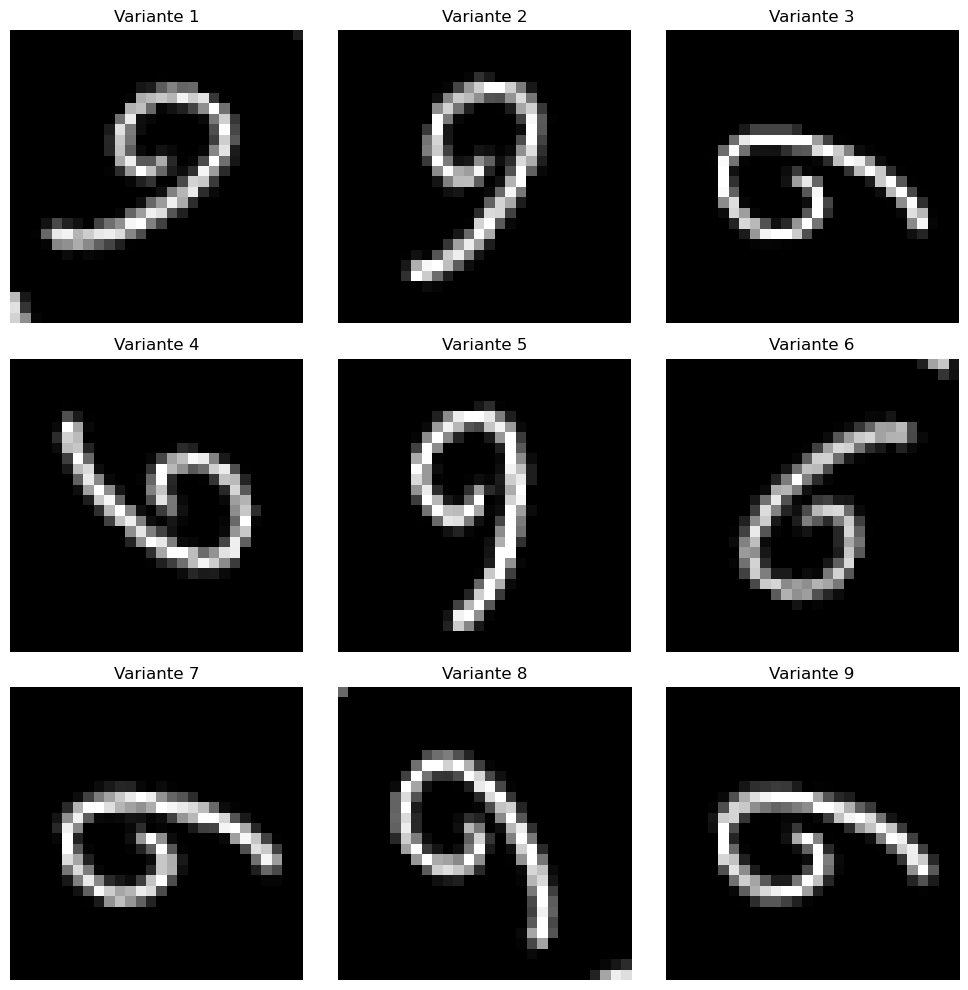

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DEFINIZIONE DELLA PIPELINE (Modificata) ---
data_augmentation = models.Sequential([
  layers.RandomRotation(0.5),          # Rotazione fino a 0.5 (±180 gradi secondo Keras, o 90 gradi se inteso come range totale)
  layers.RandomContrast(0.5),         # Aggiunto contrasto casuale
])

# --- 2. CARICAMENTO E PREPARAZIONE (Modificata su MNIST) ---
(x_train, _), _ = tf.keras.datasets.mnist.load_data() # Carichiamo MNIST invece di CIFAR10
image = x_train[18] # Prendiamo un "6" (indice 18) per testare l'invarianza
image = np.expand_dims(image, (0, -1)) # Aggiungiamo dimensione batch E canale (28, 28, 1)

# --- 3. VISUALIZZAZIONE ---
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_image = data_augmentation(image)
    
    plt.subplot(3, 3, i + 1)
    # MNIST è in scala di grigi, usiamo cmap="gray"
    plt.imshow(augmented_image[0].numpy().astype("uint8").squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Variante {i+1}")

plt.tight_layout()
plt.show()